# **Trabajo final - Fundamentos de Data Science (1ACC0216)**

# Tendencias de las estadísticas de videos de YouTube en U.S.A.

Datasets usados: **USvideos_cc50_202101.csv**, **US_category_id.json**

## 0. IMPORTACIÓN DE DEPENDENCIAS Y DATASETS INICIALES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import plotly.express as px

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option('future.no_silent_downcasting', True)

RUTA_CSV = "data/USvideos_cc50_202101.csv"
RUTA_JSON = "data/US_category_id.json"

RUTA_DATASET_CSV = "data/USvideos_cc50_202101.csv"
RUTA_DATASET_JSON = "data/US_category_id.json"

df_original = pd.read_csv(RUTA_CSV)

In [ ]:
len(df_original)

40949

## 2. COMPRENSIÓN DE LOS DATOS

In [ ]:
#solo prueba
def diagnostico_rapido(data):
    print("--- 1. Nulos por columna ---")
    print(data.isnull().sum()[data.isnull().sum() > 0])

    print("\n--- 2. Calidad de Identificadores (video_id) ---")
    ids_corruptos = (data["video_id"].astype(str).str.len() != 11).sum()
    print(f"Filas con video_id corrupto (longitud distinta a 11): {ids_corruptos}")

    print("\n--- 3. Duplicados exactos ---")
    print(f"Filas duplicadas (video_id + trending_date): {data.duplicated(subset=['video_id', 'trending_date']).sum()}")

    print("\n--- 4. Posibles Outliers (Regla del IQR 1.5) ---")
    for c in ["views", "likes", "dislikes", "comment_count"]:
        if c in data.columns:
            q1, q3 = data[c].quantile([0.25, 0.75])
            iqr = q3 - q1
            lim_sup = q3 + 1.5 * iqr
            print(f"{c}: {((data[c] > lim_sup).sum())} registros atípicos detectados")

diagnostico_rapido(df_original)

--- 1. Nulos por columna ---
description    570
dtype: int64

--- 2. Calidad de Identificadores (video_id) ---
Filas con video_id corrupto (longitud distinta a 11): 0

--- 3. Duplicados exactos ---
Filas duplicadas (video_id + trending_date): 50

--- 4. Posibles Outliers (Regla del IQR 1.5) ---
views: 4499 registros atípicos detectados
likes: 5136 registros atípicos detectados
dislikes: 5288 registros atípicos detectados
comment_count: 5089 registros atípicos detectados


## 3. PREPARACIÓN DE LOS DATOS

### 3.2. COMPRENSIÓN DE LOS DATOS

In [ ]:
#3.2
df = pd.read_csv(RUTA_DATASET_CSV)

print("Cantidad de filas:", df.shape[0])
print("Cantidad de columnas:", df.shape[1])
print()
print("Vista previa de los datos:")
df.head()

Cantidad de filas: 40949
Cantidad de columnas: 20

Vista previa de los datos:


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,state,lat,lon,geometry
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,Utah,39.419220,-111.950684,POINT (-111.950684 39.41922)
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",Nevada,39.876019,-117.224121,POINT (-117.224121 39.876019)
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,Delaware,39.000000,-75.500000,POINT (-75.5 39)
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,Delaware,39.000000,-75.500000,POINT (-75.5 39)
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,Michigan,44.182205,-84.506836,POINT (-84.50683600000001 44.182205)


### 3.2.1. Recolectar los datos iniciales

In [ ]:
#3.2.1
with open(RUTA_DATASET_JSON, encoding="utf-8") as f:
    categorias = json.load(f)

cat_map = {}
for item in categorias["items"]:
    cat_map[int(item["id"])] = item["snippet"]["title"]

df["category"] = df["category_id"].map(cat_map)

print("Datos cargados correctamente.")
print("Videos:", df.shape[0])
print("Categorias encontradas:", df["category"].nunique())
df[["video_id", "title", "category_id", "category"]].head()

Datos cargados correctamente.
Videos: 40949
Categorias encontradas: 16


,video_id,title,category_id,category
0,2kyS6SvSYSE,WE WANT TO TALK ABOUT OUR MARRIAGE,22,People & Blogs
1,1ZAPwfrtAFY,The Trump Presidency: Last Week Tonight with J...,24,Entertainment
2,5qpjK5DgCt4,"Racist Superman | Rudy Mancuso, King Bach & Le...",23,Comedy
3,puqaWrEC7tY,Nickelback Lyrics: Real or Fake?,24,Entertainment
4,d380meD0W0M,I Dare You: GOING BALD!?,24,Entertainment


### 3.2.2. Descripción de los datos

In [ ]:
#3.2.2
print("Tipos de datos por columna:")
print(df.dtypes)

print("\nTotal de columnas:", df.shape[1])

Tipos de datos por columna:
video_id                   object
trending_date              object
title                      object
channel_title              object
category_id                 int64
publish_time               object
tags                       object
views                       int64
likes                       int64
dislikes                    int64
comment_count               int64
thumbnail_link             object
comments_disabled            bool
ratings_disabled             bool
video_error_or_removed       bool
description                object
state                      object
lat                       float64
lon                       float64
geometry                   object
category                   object
dtype: object

Total de columnas: 21


## 3.2.3. Exploración de los datos

### 3.2.3.1. Cargar los datos

In [ ]:
#3.2.3.1
df.head(10)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,...,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,state,lat,lon,geometry,category
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,...,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,Utah,39.419220,-111.950684,POINT (-111.950684 39.41922),People & Blogs
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,...,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",Nevada,39.876019,-117.224121,POINT (-117.224121 39.876019),Entertainment
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,...,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,Delaware,39.000000,-75.500000,POINT (-75.5 39),Comedy
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,...,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,Delaware,39.000000,-75.500000,POINT (-75.5 39),Entertainment
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,...,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,Michigan,44.182205,-84.506836,POINT (-84.50683600000001 44.182205),Entertainment
5,gHZ1Qz0KiKM,17.14.11,2 Weeks with iPhone X,iJustine,28,2017-11-13T19:07:23.000Z,"ijustine|""week with iPhone X""|""iphone x""|""appl...",119180,9763,511,...,https://i.ytimg.com/vi/gHZ1Qz0KiKM/default.jpg,False,False,False,Using the iPhone for the past two weeks -- her...,Florida,27.994402,-81.760254,POINT (-81.760254 27.994402),Science & Technology
6,39idVpFF7NQ,17.14.11,Roy Moore & Jeff Sessions Cold Open - SNL,Saturday Night Live,24,2017-11-12T05:37:17.000Z,"SNL|""Saturday Night Live""|""SNL Season 43""|""Epi...",2103417,15993,2445,...,https://i.ytimg.com/vi/39idVpFF7NQ/default.jpg,False,False,False,Embattled Alabama Senate candidate Roy Moore (...,West Virginia,39.000000,-80.500000,POINT (-80.5 39),Entertainment
7,nc99ccSXST0,17.14.11,5 Ice Cream Gadgets put to the Test,CrazyRussianHacker,28,2017-11-12T21:50:37.000Z,"5 Ice Cream Gadgets|""Ice Cream""|""Cream Sandwic...",817732,23663,778,...,https://i.ytimg.com/vi/nc99ccSXST0/default.jpg,False,False,False,Ice Cream Pint Combination Lock - http://amzn....,New Hampshire,44.000000,-71.500000,POINT (-71.5 44),Science & Technology
8,jr9QtXwC9vc,17.14.11,The Greatest Showman | Official Trailer 2 [HD]...,20th Century Fox,1,2017-11-13T14:00:23.000Z,"Trailer|""Hugh Jackman""|""Michelle Williams""|""Za...",826059,3543,119,...,https://i.ytimg.com/vi/jr9QtXwC9vc/default.jpg,False,False,False,"Inspired by the imagination of P.T. Barnum, Th...",South Carolina,33.836082,-81.163727,POINT (-81.16372699999999 33.836082),Film & Animation
9,TUmyygCMMGA,17.14.11,Why the rise of the robots won’t mean the end ...,Vox,25,2017-11-13T13:45:16.000Z,"vox.com|""vox""|""explain""|""shift change""|""future...",256426,12654,1363,...,https://i.ytimg.com/vi/TUmyygCMMGA/default.jpg,False,False,False,"For now, at least, we have better things to wo...",Wyoming,43.075970,-107.290283,POINT (-107.290283 43.07597),News & Politics


### 3.2.3.2. Inspeccionar los datos

In [ ]:
#3.2.3.2
df.info()
df[["views", "likes", "dislikes", "comment_count"]].describe()
df["category"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   video_id                40949 non-null  object 
 1   trending_date           40949 non-null  object 
 2   title                   40949 non-null  object 
 3   channel_title           40949 non-null  object 
 4   category_id             40949 non-null  int64  
 5   publish_time            40949 non-null  object 
 6   tags                    40949 non-null  object 
 7   views                   40949 non-null  int64  
 8   likes                   40949 non-null  int64  
 9   dislikes                40949 non-null  int64  
 10  comment_count           40949 non-null  int64  
 11  thumbnail_link          40949 non-null  object 
 12  comments_disabled       40949 non-null  bool   
 13  ratings_disabled        40949 non-null  bool   
 14  video_error_or_removed  40949 non-null

,count
category,
Entertainment,9964
Music,6472
Howto & Style,4146
Comedy,3457
People & Blogs,3210
News & Politics,2487
Science & Technology,2401
Film & Animation,2345
Sports,2174


### 3.2.3.3. Visualizar los datos

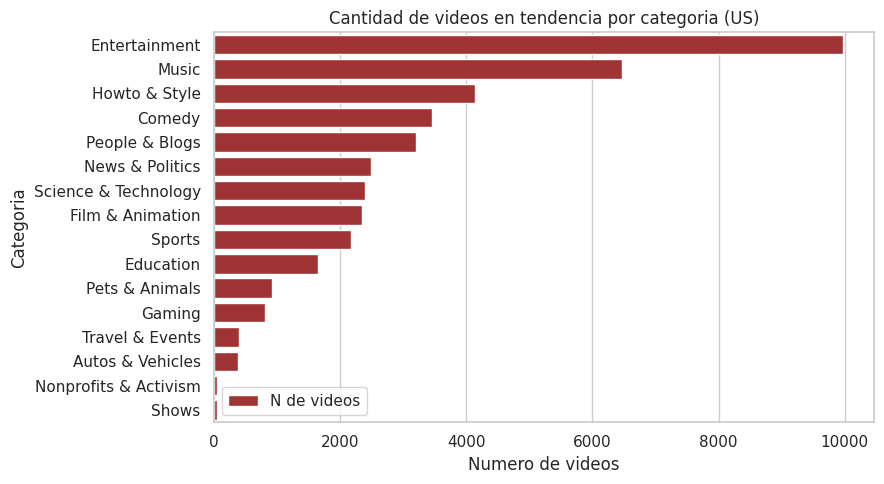

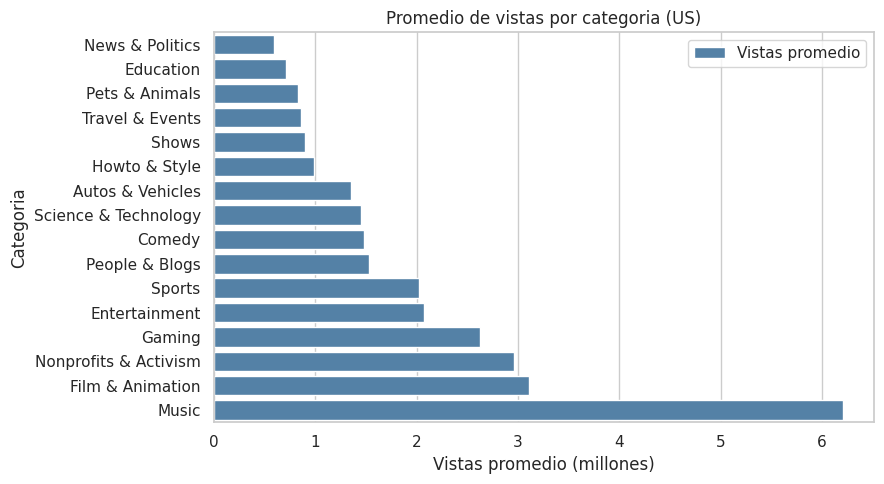

In [ ]:
#3.2.3.3
#grafico1
frecuencia = df["category"].value_counts()

plt.figure(figsize=(9, 5))
sns.barplot(x=frecuencia.values, y=frecuencia.index, color="firebrick", label="N de videos")
plt.title("Cantidad de videos en tendencia por categoria (US)")
plt.xlabel("Numero de videos")
plt.ylabel("Categoria")
plt.legend()
plt.tight_layout()
plt.show()
#grafico2
promedio = df.groupby("category")["views"].mean().sort_values() / 1_000_000

plt.figure(figsize=(9, 5))
sns.barplot(x=promedio.values, y=promedio.index, color="steelblue", label="Vistas promedio")
plt.title("Promedio de vistas por categoria (US)")
plt.xlabel("Vistas promedio (millones)")
plt.ylabel("Categoria")
plt.legend()
plt.tight_layout()
plt.show()

### 3.2.4. Verificar la calidad de los datos

In [ ]:
#3.2.4
print("Valores nulos por columna:")
print(df.isnull().sum())

print("\nFilas duplicadas:", df.duplicated().sum())

print("\nMinimos de las metricas:")
print(df[["views", "likes", "dislikes", "comment_count"]].min())

Valores nulos por columna:
video_id                    0
trending_date               0
title                       0
channel_title               0
category_id                 0
publish_time                0
tags                        0
views                       0
likes                       0
dislikes                    0
comment_count               0
thumbnail_link              0
comments_disabled           0
ratings_disabled            0
video_error_or_removed      0
description               570
state                       0
lat                         0
lon                         0
geometry                    0
category                    0
dtype: int64

Filas duplicadas: 1

Minimos de las metricas:
views            549
likes              0
dislikes           0
comment_count      0
dtype: int64


# 3.3. Limpiar los datos

In [ ]:
def limpiar_datos(df):
    data = df.copy()

    cols_clave = ["video_id", "views", "likes", "dislikes", "comment_count"]
    data = data.dropna(subset=cols_clave)

    data = data[data["video_id"].astype(str).str.len() == 11]

    data["description"] = data["description"].fillna("Sin descripcion")

    data["trending_date"] = pd.to_datetime(data["trending_date"], format="%y.%d.%m", errors="coerce")
    data["publish_time"] = pd.to_datetime(data["publish_time"], errors="coerce")
    data["category_id"] = pd.to_numeric(data["category_id"], errors="coerce").astype("Int64")

    dicc_bool = {"True": True, "False": False, "VERDADERO": True, "FALSO": False}
    cols_bool = ["comments_disabled", "ratings_disabled", "video_error_or_removed"]
    for c in cols_bool:
        if c in data.columns:
            data[c] = data[c].replace(dicc_bool).infer_objects(copy=False)

    dups = data.duplicated(subset=["video_id", "trending_date"]).sum()
    data = data.drop_duplicates(subset=["video_id", "trending_date"], keep="first")
    print(f"Se eliminaron {dups} duplicados exactos.")

    return data.reset_index(drop=True)

df_limpio = limpiar_datos(df_original)
print("Dimensiones tras limpieza:", df_limpio.shape)

Se eliminaron 50 duplicados exactos.
Dimensiones tras limpieza: (40899, 20)


### 3.3. Identificación de outliers

In [ ]:
def preprocesar(df):
    data = df.copy()

    data = data.dropna(subset=["trending_date", "publish_time"])

    if data["publish_time"].dt.tz is not None:
        data["publish_time"] = data["publish_time"].dt.tz_localize(None)

    data["dias_para_tendencia"] = (data["trending_date"] - data["publish_time"]).dt.days
    malos_tiempos = (data["dias_para_tendencia"] < 0).sum()
    print(f"Borrando {malos_tiempos} registros con fechas ilógicas.")
    data = data[data["dias_para_tendencia"] >= 0]

    for col in ["views", "likes", "dislikes", "comment_count"]:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        limite = q3 + 3 * (q3 - q1)

        data[f"{col}_outlier"] = data[col] > limite
        print(f"Outliers marcados en {col}: {data[f'{col}_outlier'].sum()}")

    columnas_flag = [f"{c}_outlier" for c in ["views", "likes", "dislikes", "comment_count"]]
    data["es_outlier"] = data[columnas_flag].any(axis=1)

    pct = data['es_outlier'].mean() * 100
    print(f"\nTotal de videos 'virales' (outliers): {data['es_outlier'].sum()} ({pct:.2f}%)")

    return data.reset_index(drop=True)

df_procesado = preprocesar(df_limpio)
print("Dimensiones preprocesadas:", df_procesado.shape)

Borrando 120 registros con fechas ilógicas.
Outliers marcados en views: 2853
Outliers marcados en likes: 3060
Outliers marcados en dislikes: 3516
Outliers marcados en comment_count: 3235

Total de videos 'virales' (outliers): 5540 (13.59%)
Dimensiones preprocesadas: (40779, 26)


### 3.3 Construir nuevos datos (feature engineering)

In [ ]:
def crear_datos(df, json_path):
    data = df.copy()

    with open(json_path, encoding="utf-8") as f:
        categorias = json.load(f)

    dict_cat = {int(x["id"]): x["snippet"]["title"] for x in categorias["items"]}
    data["category_name"] = data["category_id"].map(dict_cat).fillna("Sin categoria")

    # Ratios de negocio solicitados
    data["ratio_likes_dislikes"] = data["likes"] / data["dislikes"].replace(0, np.nan)
    data["ratio_views_comments"] = data["views"] / data["comment_count"].replace(0, np.nan)

    # Tasa de interacción
    reacciones = data["likes"] + data["dislikes"] + data["comment_count"]
    data["tasa_interaccion"] = reacciones / data["views"].replace(0, np.nan)

    # Variables de tiempo
    data["dia_semana_publicacion"] = data["publish_time"].dt.day_name()
    data["es_fin_semana"] = data["publish_time"].dt.dayofweek >= 5
    data["hora_publicacion"] = data["publish_time"].dt.hour
    data["mes_tendencia"] = data["trending_date"].dt.to_period("M").astype(str)

    if "tags" in data.columns:
        data["cantidad_tags"] = data["tags"].fillna("").apply(
            lambda x: 0 if x.strip() in ("", "[none]") else len(x.split("|"))
        )
    data["long_titulo"] = data["title"].astype(str).str.len()

    for col in data.select_dtypes(include=["int64", "float64"]).columns:
        data[col] = pd.to_numeric(data[col], downcast="integer")

    cols_categoricas = ["category_name", "dia_semana_publicacion", "mes_tendencia"]
    for c in cols_categoricas:
        data[c] = data[c].astype("category")

    return data

df_final = crear_datos(df_procesado, RUTA_JSON)

mem_antes = df_procesado.memory_usage(deep=True).sum() / (1024**2)
mem_despues = df_final.memory_usage(deep=True).sum() / (1024**2)

print(f"Dimensiones finales: {df_final.shape}")
print(f"Memoria RAM reducida de {mem_antes:.2f} MB a {mem_despues:.2f} MB")

cols_resumen = ["ratio_likes_dislikes", "ratio_views_comments", "tasa_interaccion", "cantidad_tags", "long_titulo"]
display(df_final[cols_resumen].describe())

Dimensiones finales: (40779, 36)
Memoria RAM reducida de 111.06 MB a 111.26 MB


,ratio_likes_dislikes,ratio_views_comments,tasa_interaccion,cantidad_tags,long_titulo
count,40397.000000,4.002800e+04,40779.000000,40779.000000,40779.000000
mean,43.987421,1.149891e+03,0.040386,19.702862,48.569288
std,51.412003,4.988991e+04,0.030025,12.070398,19.622842
min,0.000000,8.500294e+00,0.000000,0.000000,3.000000
25%,13.293069,1.899873e+02,0.019140,10.000000,34.000000
50%,29.137193,3.310624e+02,0.033797,19.000000,46.000000
75%,56.457534,5.990627e+02,0.053726,29.000000,61.000000
max,1737.333333,8.001593e+06,0.296893,69.000000,100.000000


In [ ]:
RUTA_SALIDA = "USvideos_limpio.csv"
df_final.to_csv(RUTA_SALIDA, index=False)
print(f"Dataset limpio exportado: {df_final.shape[0]} filas, {df_final.shape[1]} columnas")

Dataset limpio exportado: 40779 filas, 36 columnas


### 3.4. Respuesta a los requerimientos

### Por Categoría de Videos

1. ¿Qué categorías de videos son las de mayor tendencia?

In [ ]:
df_videos_unicos = (
    df_final.sort_values("trending_date")
    .drop_duplicates(subset="video_id", keep="last")
)
print("Apariciones totales en tendencia:", len(df_final))
print("Videos únicos:", len(df_videos_unicos))

Apariciones totales en tendencia: 40779
Videos únicos: 6334


--- Tabla de Apariciones por Categoría en EE. UU. ---


,category_name,apariciones_en_tendencia
0,Entertainment,9905
1,Music,6446
2,Howto & Style,4141
3,Comedy,3441
4,People & Blogs,3201
5,News & Politics,2479
6,Science & Technology,2386
7,Film & Animation,2338
8,Sports,2164
9,Education,1653


/tmp/ipykernel_361/3723059354.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




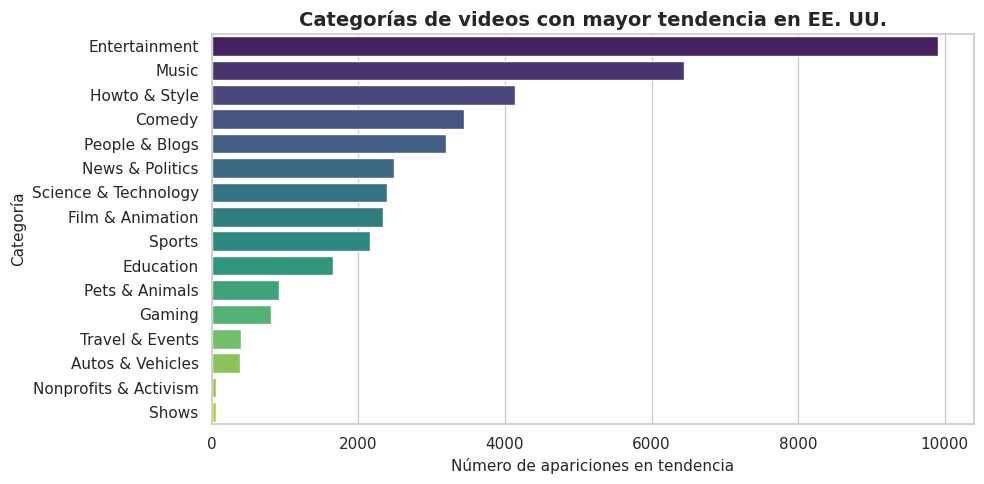

In [ ]:
req1_data = df_final["category_name"].value_counts().reset_index()
req1_data.columns = ["category_name", "apariciones_en_tendencia"]

req1_data = req1_data.sort_values(by="apariciones_en_tendencia", ascending=False)

print("--- Tabla de Apariciones por Categoría en EE. UU. ---")
display(req1_data)

sns.barplot(
    data=req1_data,
    x="apariciones_en_tendencia",
    y="category_name",
    palette="viridis",
    order=req1_data["category_name"]
)

plt.title("Categorías de videos con mayor tendencia en EE. UU.", fontsize=14, fontweight='bold')
plt.xlabel("Número de apariciones en tendencia", fontsize=11)
plt.ylabel("Categoría", fontsize=11)

plt.tight_layout()
plt.show()

2. ¿Qué categorías de videos son los que más gustan? ¿Y las que menos gustan?

--- Tabla de Promedio de Likes por Categoría ---


/tmp/ipykernel_361/497643181.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,category_name,promedio_likes
7,Music,188495.048811
9,Nonprofits & Activism,170616.000000
5,Gaming,68392.277228
1,Comedy,55372.042514
4,Film & Animation,52123.806250
10,People & Blogs,46464.975758
3,Entertainment,41797.958462
6,Howto & Style,34758.220539
14,Sports,28074.037946
12,Science & Technology,26682.409449


/tmp/ipykernel_361/497643181.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




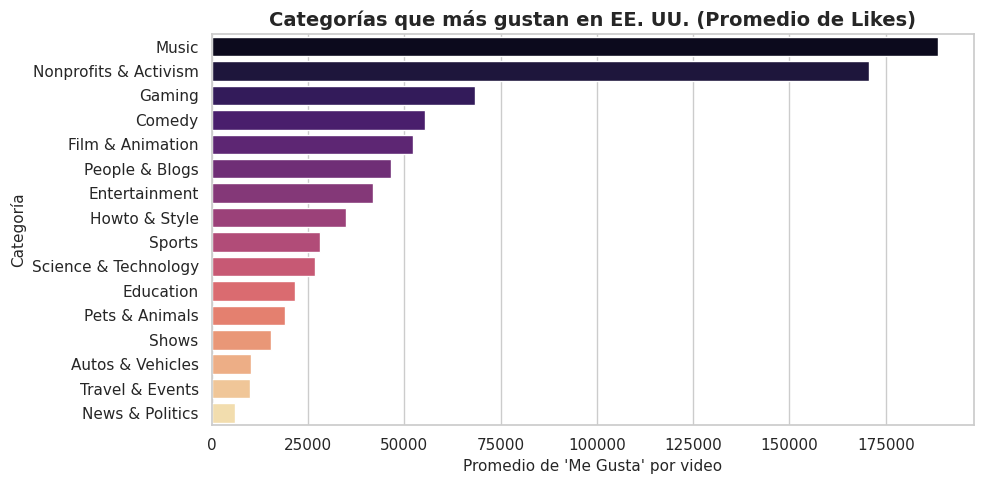

In [ ]:
df_unicos = df_final.drop_duplicates(subset=["video_id"], keep="last")

req2_data = df_unicos.groupby("category_name")["likes"].mean().reset_index()
req2_data.columns = ["category_name", "promedio_likes"]
req2_data = req2_data.sort_values(by="promedio_likes", ascending=False)

print("--- Tabla de Promedio de Likes por Categoría ---")
display(req2_data)

sns.barplot(
    data=req2_data,
    x="promedio_likes",
    y="category_name",
    palette="magma",
    order=req2_data["category_name"]
)
plt.title("Categorías que más gustan en EE. UU. (Promedio de Likes)", fontsize=14, fontweight='bold')
plt.xlabel("Promedio de 'Me Gusta' por video", fontsize=11)
plt.ylabel("Categoría", fontsize=11)
plt.tight_layout()
plt.show()

3. ¿Qué categorías de videos tienen la mejor proporción (ratio) de “Me gusta” / “No me gusta”?

--- Tabla de Ratio Likes/Dislikes por Categoría ---


/tmp/ipykernel_361/1516808033.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,category_name,ratio_likes_dislikes
11,Pets & Animals,69.125707
7,Music,60.858777
10,People & Blogs,57.170761
6,Howto & Style,50.285365
2,Education,47.213911
1,Comedy,43.365512
12,Science & Technology,42.055249
5,Gaming,38.675228
3,Entertainment,37.314322
4,Film & Animation,36.251254


/tmp/ipykernel_361/1516808033.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




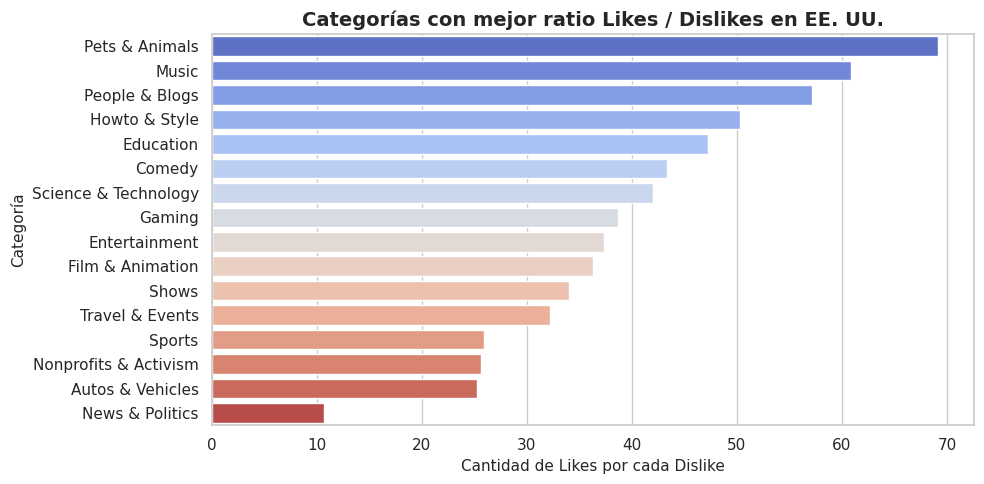

In [ ]:
req3_data = df_unicos.groupby("category_name")["ratio_likes_dislikes"].mean().reset_index()
req3_data = req3_data.sort_values(by="ratio_likes_dislikes", ascending=False)

print("--- Tabla de Ratio Likes/Dislikes por Categoría ---")
display(req3_data)

sns.barplot(
    data=req3_data,
    x="ratio_likes_dislikes",
    y="category_name",
    palette="coolwarm",
    order=req3_data["category_name"]
)
plt.title("Categorías con mejor ratio Likes / Dislikes en EE. UU.", fontsize=14, fontweight='bold')
plt.xlabel("Cantidad de Likes por cada Dislike", fontsize=11)
plt.ylabel("Categoría", fontsize=11)
plt.tight_layout()
plt.show()

4. ¿Qué categorías de videos tienen la mejor proporción (ratio) de “Vistas” /
“Comentarios”?

--- Tabla de Ratio Vistas/Comentarios por Categoría ---


/tmp/ipykernel_361/386940844.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,category_name,ratio_views_comments
7,Music,10706.598585
0,Autos & Vehicles,8484.947036
15,Travel & Events,1969.995560
4,Film & Animation,1593.171425
3,Entertainment,1218.529271
14,Sports,958.890692
1,Comedy,653.563615
12,Science & Technology,636.113574
9,Nonprofits & Activism,628.066612
8,News & Politics,601.810420


/tmp/ipykernel_361/386940844.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




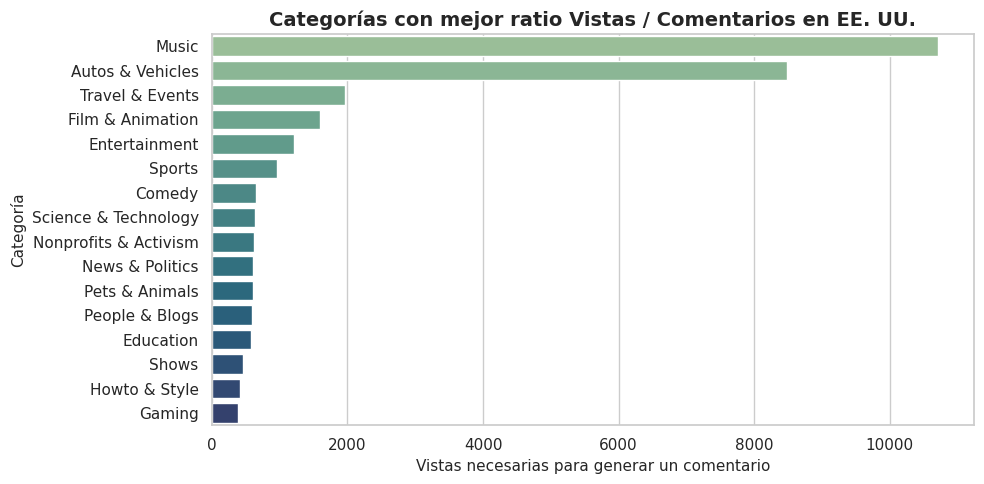

In [ ]:
req4_data = df_unicos.groupby("category_name")["ratio_views_comments"].mean().reset_index()
req4_data = req4_data.sort_values(by="ratio_views_comments", ascending=False)

print("--- Tabla de Ratio Vistas/Comentarios por Categoría ---")
display(req4_data)

sns.barplot(
    data=req4_data,
    x="ratio_views_comments",
    y="category_name",
    palette="crest",
    order=req4_data["category_name"]
)
plt.title("Categorías con mejor ratio Vistas / Comentarios en EE. UU.", fontsize=14, fontweight='bold')
plt.xlabel("Vistas necesarias para generar un comentario", fontsize=11)
plt.ylabel("Categoría", fontsize=11)
plt.tight_layout()
plt.show()

### Por el tiempo transcurrido

5. ¿Cómo ha cambiado el volumen de los videos en tendencia a lo largo del tiempo?

--- Tabla de Evolución Temporal ---


/tmp/ipykernel_361/2376524518.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,mes_tendencia,volumen_videos
0,2017-11,3385
1,2017-12,6172
2,2018-01,5764
3,2018-02,5539
4,2018-03,6178
5,2018-04,4799
6,2018-05,6146
7,2018-06,2796


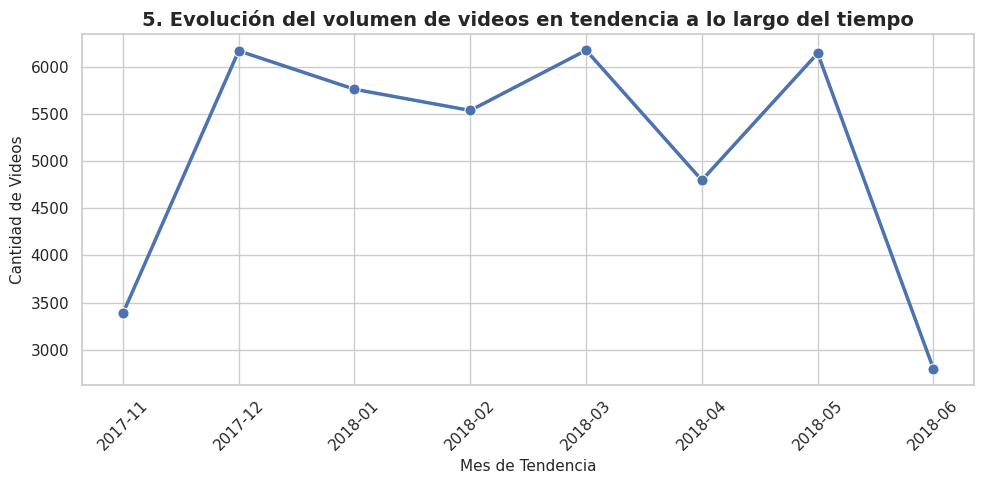

In [ ]:
req5_data = df_final.groupby("mes_tendencia").size().reset_index(name="volumen_videos")
req5_data = req5_data.sort_values(by="mes_tendencia")

print("--- Tabla de Evolución Temporal ---")
display(req5_data)

sns.lineplot(
    data=req5_data,
    x="mes_tendencia",
    y="volumen_videos",
    marker="o",
    color="b",
    linewidth=2.5,
    markersize=8
)

plt.title("5. Evolución del volumen de videos en tendencia a lo largo del tiempo", fontsize=14, fontweight='bold')
plt.xlabel("Mes de Tendencia", fontsize=11)
plt.ylabel("Cantidad de Videos", fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Por Canales de YouTube

6. ¿Qué Canales de YouTube son tendencia más frecuentemente? ¿Y cuáles con menos
frecuencia?

/tmp/ipykernel_361/3068402858.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




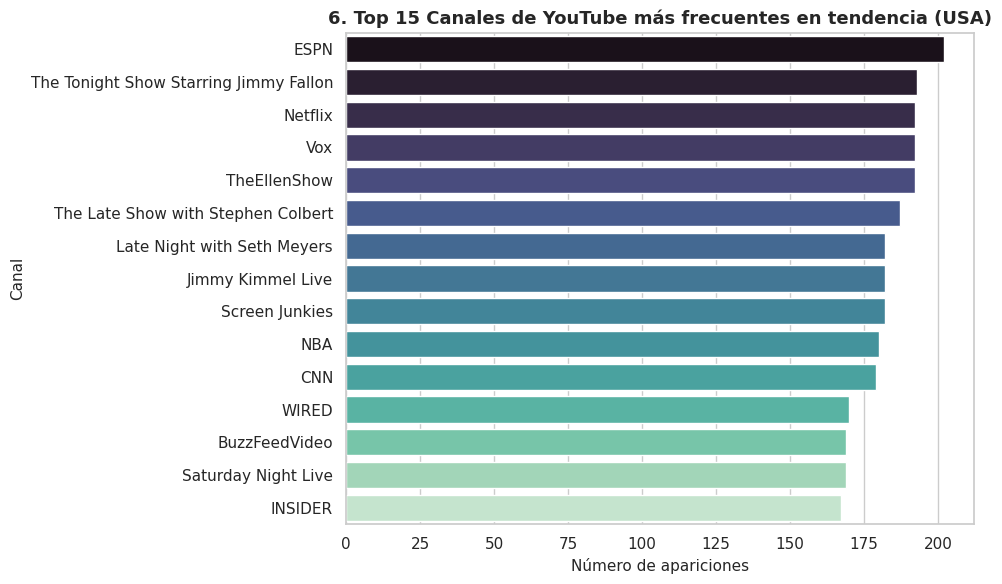


Hay una 'larga cola' de creadores. 126 canales de 2204 (5.7%) aparecieron en tendencia una sola vez.


In [ ]:
conteo_canales = df_final["channel_title"].value_counts()
top_15_canales = conteo_canales.head(15).reset_index()
top_15_canales.columns = ["Canal", "Apariciones"]

plt.figure(figsize=(10, 6))
sns.barplot(data=top_15_canales, x="Apariciones", y="Canal", palette="mako")
plt.title("6. Top 15 Canales de YouTube más frecuentes en tendencia (USA)", fontsize=13, fontweight="bold")
plt.xlabel("Número de apariciones", fontsize=11)
plt.ylabel("Canal", fontsize=11)
plt.tight_layout()
plt.show()

# Dato extra para responder "cuáles con menos frecuencia"
canales_una_vez = (conteo_canales == 1).sum()
print(f"\nHay una 'larga cola' de creadores. {canales_una_vez} canales de {len(conteo_canales)} "
      f"({(canales_una_vez/len(conteo_canales))*100:.1f}%) aparecieron en tendencia una sola vez.")

### Por la geografía del país

7. ¿En qué Estados se presenta el mayor número de “Vistas”, “Me gusta” y “No me
gusta”?

In [ ]:
df_geo = df_procesado.drop_duplicates(subset=["video_id"], keep="last")

r7_geo = df_geo.groupby("state").agg(
    views=("views", "sum"),
    likes=("likes", "sum"),
    dislikes=("dislikes", "sum"),
    lat=("lat", "first"),
    lon=("lon", "first")
).reset_index()

print("--- Top 5 Estados con más Vistas ---")
display(r7_geo.sort_values("views", ascending=False).head())

fig = px.scatter_geo(
    r7_geo,
    lat="lat",
    lon="lon",
    size="likes",
    color="likes",
    hover_name="state",
    hover_data={"views": True, "dislikes": True, "lat": False, "lon": False},
    scope="usa",
    title="USA - Likes en Videos de Youtube por Estado",
    color_continuous_scale="plasma"
)

fig.update_layout(title_font_size=16, margin={"r":0,"t":40,"l":0,"b":0})
fig.show()

--- Top 5 Estados con más Vistas ---


,state,views,likes,dislikes,lat,lon
19,Maryland,486010470,12328256,742850,39.045753,-76.641273
17,Louisiana,446179315,11390594,476489,30.391830,-92.329102
8,Florida,411033302,13484587,530920,27.994402,-81.760254
25,Montana,391669210,8247623,412476,46.965260,-109.533691
40,South Dakota,380954243,8558715,322448,44.500000,-100.000000


### Preguntas adicionales

8. ¿Los videos en tendencia son los que mayor cantidad de comentarios positivos
reciben?

--- Matriz de Correlación ---


,dias_en_tendencia,comment_count,ratio_likes_dislikes,views
dias_en_tendencia,1.000000,0.117548,-0.010673,0.258309
comment_count,0.117548,1.000000,0.018049,0.573856
ratio_likes_dislikes,-0.010673,0.018049,1.000000,-0.027149
views,0.258309,0.573856,-0.027149,1.000000


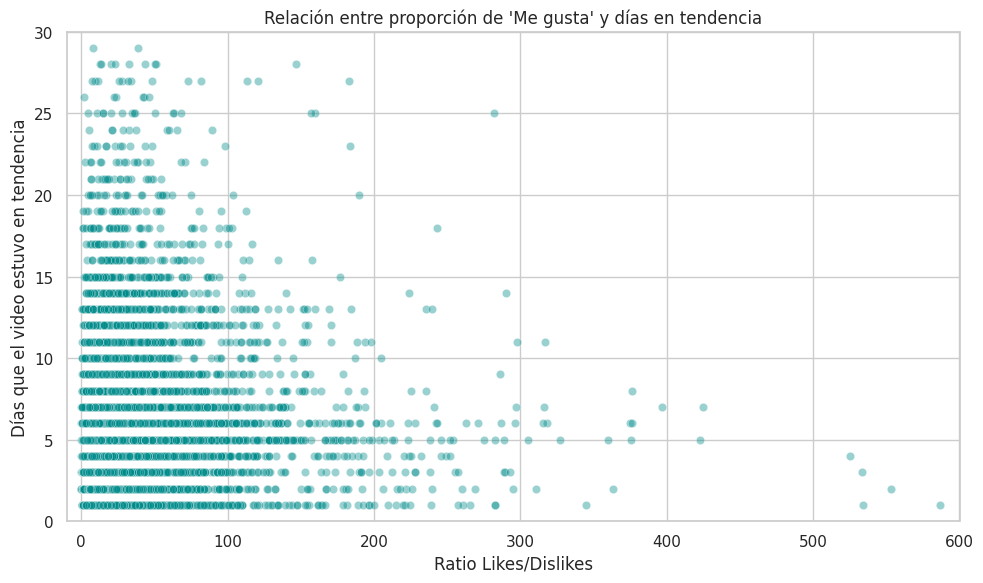

In [ ]:
df_video = df_final.drop_duplicates(subset=["video_id"], keep="last")

apariciones_por_video = df_final.groupby("video_id").size().rename("dias_en_tendencia")

df_r8 = df_video.merge(apariciones_por_video, on="video_id")

corr = df_r8[["dias_en_tendencia", "comment_count", "ratio_likes_dislikes", "views"]].corr()

print("--- Matriz de Correlación ---")
display(corr)

plt.figure(figsize=(10, 6))
plt.xlim(-10, 600)
plt.ylim(0, 30)
sns.scatterplot(data=df_r8, x="ratio_likes_dislikes", y="dias_en_tendencia", alpha=0.4, color="darkcyan")

plt.title("Relación entre proporción de 'Me gusta' y días en tendencia")
plt.xlabel("Ratio Likes/Dislikes")
plt.ylabel("Días que el video estuvo en tendencia")
plt.tight_layout()
plt.show()

9. ¿Es factible predecir el número de “Vistas” o “Me gusta” o “No me gusta”?

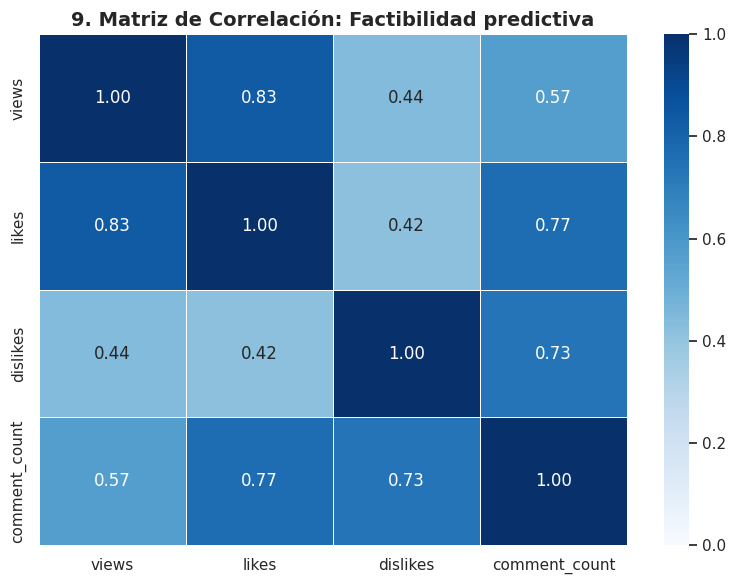

Análisis de factibilidad:
Si las correlaciones son superiores a 0.7, la predicción es altamente factible mediante algoritmos lineales.


In [ ]:
cols_pred = ["views", "likes", "dislikes", "comment_count"]
matriz_corr = df_r8[cols_pred].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap="Blues", fmt=".2f", vmin=0, vmax=1, linewidths=0.5)

plt.title("9. Matriz de Correlación: Factibilidad predictiva", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Análisis de factibilidad:")
print("Si las correlaciones son superiores a 0.7, la predicción es altamente factible mediante algoritmos lineales.")

## 4. MODELADO Y EVALUACIÓN DE RESULTADOS

## 3.4. MODELADO Y EVALUACIÓN DE RESULTADOS
En esta fase se busca establecer las técnicas de modelado más apropiadas para el proyecto de Data Mining específico de acuerdo con los objetivos planteados.

### 3.4.1. Escoger la técnica de modelado
Esta tarea consiste en la selección de la técnica de Data Mining más apropiada al tipo de problema que se quiere resolver. Por ejemplo, si el problema es de predicción: análisis de regresión lineal/regresión logística.

**Decisión del Equipo:** Dado que nuestro objetivo principal es predecir un valor numérico continuo (la cantidad de vistas `views` de un video en YouTube), estamos ante un problema de Regresión. Por ello, seleccionamos dos algoritmos para comparar sus resultados:
1. **Regresión Lineal Múltiple:** Como modelo base estadístico.
2. **Bosques Aleatorios (Random Forest Regressor):** Como modelo avanzado de Machine Learning capaz de capturar relaciones no lineales.

### 3.4.2. Generar el plan de prueba
Una vez determinado el modelo, se construye y adicionalmente se debe generar un procedimiento destinado a probar la calidad y validez de este. Por ejemplo, en una tarea supervisada de Data Mining como la clasificación, es común usar la razón de error como medida de la calidad. Entonces, típicamente se separan los datos en dos conjuntos, uno de entrenamiento y otro de prueba.

**Plan del Equipo:** Procederemos a separar nuestro conjunto de datos (proveniente de `USvideos_limpio.csv`) dividiéndolo en un subconjunto de Entrenamiento (80% de los datos) y un subconjunto de Prueba (20%).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

df = pd.read_csv('USvideos_limpio.csv')
print(f"Total de registros cargados: {df.shape[0]}")

X = df[['likes', 'dislikes', 'comment_count', 'dias_para_tendencia', 'long_titulo', 'cantidad_tags']]
y = df['views']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos destinados para Entrenamiento: {X_train.shape[0]} registros")
print(f"Datos destinados para Prueba: {X_test.shape[0]} registros")

Total de registros cargados: 40779
Datos destinados para Entrenamiento: 32623 registros
Datos destinados para Prueba: 8156 registros


### 3.4.3. Construir el modelo
A continuación, se ejecuta la técnica seleccionada sobre los datos previamente preparados para generar uno o más modelos.

In [ ]:

# Modelo 1: Regresión Lineal
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

# Modelo 2: Random Forest
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

print("Modelos construidos y entrenados exitosamente.")

Modelos construidos y entrenados exitosamente.


### 3.4.4. Evaluar el modelo
Aplicar métricas que permitan determinar el rendimiento del modelo en cuanto a la precisión y/o exactitud de los resultados obtenidos.

**Métricas y Visualizaciones a utilizar:**
- **R² (Coeficiente de Determinación) y MAE (Error Absoluto Medio).**
- **Gráfico de Predicciones vs. Valores Reales:** Para observar gráficamente qué tan cerca estuvieron las predicciones (Random Forest) de la realidad. Una línea diagonal perfecta a 45 grados representaría una predicción sin errores.

--- Rendimiento de Regresión Lineal ---
R² Score : 0.7746
MAE      : 1,164,102.69 vistas

--- Rendimiento de Random Forest ---
R² Score : 0.9764
MAE      : 328,564.12 vistas



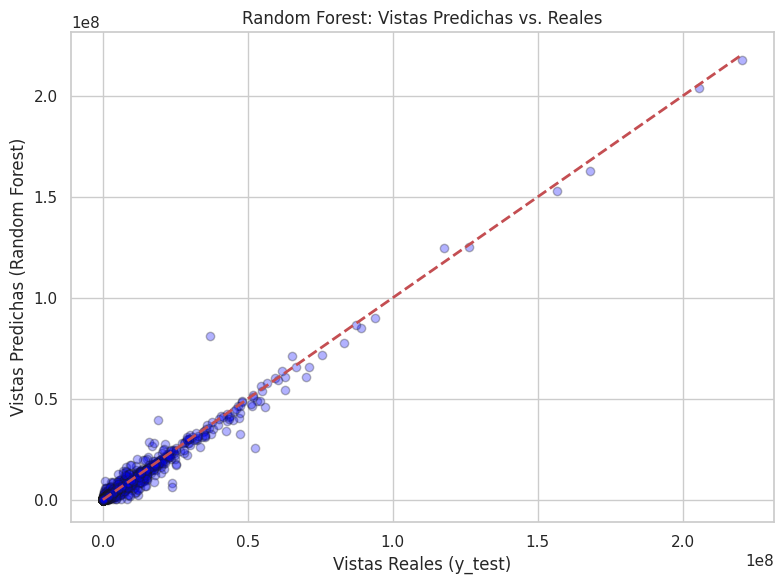

In [ ]:
# Realizar predicciones con el conjunto de prueba
predicciones_lr = modelo_lr.predict(X_test)
predicciones_rf = modelo_rf.predict(X_test)

def evaluar_rendimiento(nombre, y_real, y_pred):
    r2 = r2_score(y_real, y_pred)
    mae = mean_absolute_error(y_real, y_pred)
    print(f"--- Rendimiento de {nombre} ---")
    print(f"R² Score : {r2:.4f}")
    print(f"MAE      : {mae:,.2f} vistas\n")

evaluar_rendimiento("Regresión Lineal", y_test, predicciones_lr)
evaluar_rendimiento("Random Forest", y_test, predicciones_rf)

# --- GRÁFICO 1: ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predicciones_rf, alpha=0.3, color='blue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Vistas Reales (y_test)')
plt.ylabel('Vistas Predichas (Random Forest)')
plt.title('Random Forest: Vistas Predichas vs. Reales')
plt.tight_layout()
plt.show()